# Network Analysis

 This notebook analyses the structure of the inferred gene regulatory networks

 (GRNs) stored in `adata.varp['W_<cluster>']`.



 Topics covered:

 1. Network correlation dendrograms

 2. Symmetricity of W matrices

 3. Network centrality (degree, betweenness, eigenvector)

 4. Eigenanalysis of interaction matrices

 5. GRN visualisation

 ## Setup

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as scp
from scipy.spatial.distance import squareform 
import scHopfield as sch

DATA_PATH    = './scratch/Data/'
DATASET_FILE = 'hematopoiesis.h5ad'
MODEL_FILE   = 'model.h5sch'

CLUSTER_KEY = 'cell_type'
SPLICED_KEY  = 'M_t'

CELL_TYPE_ORDER = ['Meg', 'Ery', 'MEP-like', 'HSC', 'GMP-like', 'Mon', 'Bas', 'Neu']

adata = sc.read_h5ad(DATA_PATH + DATASET_FILE)
adata = sch.tl.load_model(adata, MODEL_FILE)
print(adata)

# Cell-type colour palette
colors = dict(zip(CELL_TYPE_ORDER, adata.uns['cell_type_colors']))


/tmp/ipykernel_1221845/4162748082.py:19: UserWarning: adata has 1956 genes but the model was trained on 1728.  A subsetted copy is being returned; the original adata is NOT modified.  Reassign the return value:
    adata = sch.tl.load_model(adata, filename)
  adata = sch.tl.load_model(adata, MODEL_FILE)


Model loaded from 'model.h5sch'  |  clusters=['Bas', 'Ery', 'GMP-like', 'HSC', 'MEP-like', 'Meg', 'Mon', 'Neu', 'all']  |  genes=1728
AnnData object with n_obs × n_vars = 1947 × 1728
    obs: 'batch', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'new_Size_Factor', 'initial_new_cell_size', 'total_Size_Factor', 'initial_total_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr', 'cell_cycle_phase', 'leiden', 'control_point_pca', 'inlier_prob_pca', 'obs_vf_angle_pca', 'pca_ddhodge_div', 'pca_ddhodge_potential', 'acceleration_pca', 'curvature_pca', 'n_counts', 'mt_frac', 'jacobian_det_pca', 'manual_selection', 'divergence_pca', 'curv_leiden', 'curv_louvain', 'SPI1->GATA1_jacobian', 'jacobian', 'umap_ori_leiden', 'umap_ori_louvain', 'umap_ddhodge_div', 'umap_ddhodge_potential', 'curl_umap', 'divergence_umap', 'acceleration_umap', 'control_point_umap_ori', '

 ## 3.1 Network Correlation Dendrograms



 Compute pairwise similarity between cell-type networks using the RV coefficient

 and Pearson / Hamming distances.

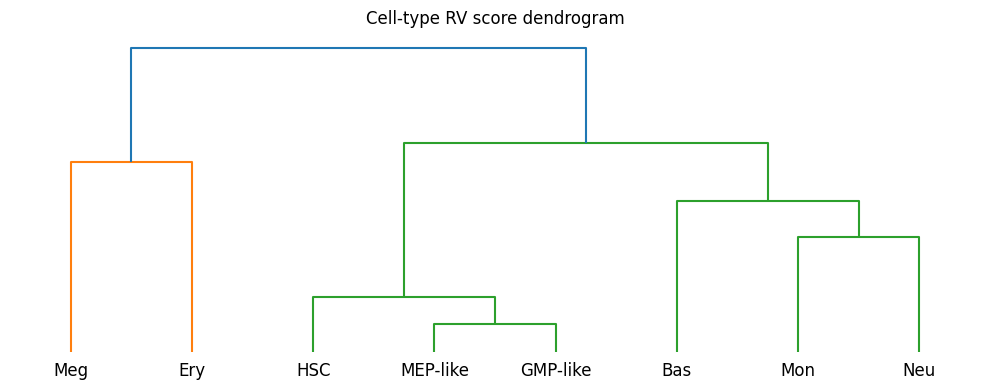

In [16]:
# Cell-type similarity based on expression covariance (RV score)
sch.tl.celltype_correlation(
    adata,
    spliced_key=SPLICED_KEY,
    cluster_key=CLUSTER_KEY
)

cells_correlation = adata.uns['scHopfield']['celltype_correlation']

fig, ax = plt.subplots(figsize=(10, 4), tight_layout=True)
Z = scp.cluster.hierarchy.linkage(squareform(1 - cells_correlation), 'complete')
scp.cluster.hierarchy.dendrogram(Z, labels=cells_correlation.index, ax=ax)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_title('Cell-type RV score dendrogram')
plt.show()


/home/bernaljp/miniconda3/envs/SCH/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/bernaljp/miniconda3/envs/SCH/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


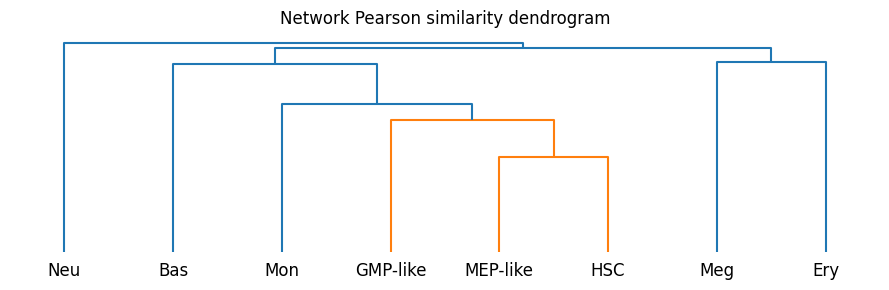

In [17]:
# Network-structure similarity (W matrix correlations)
sch.tl.network_correlations(adata, cluster_key=CLUSTER_KEY)

pearson    = adata.uns['scHopfield']['network_correlations']['pearson']
hamming    = adata.uns['scHopfield']['network_correlations']['hamming']
pearson_bin = adata.uns['scHopfield']['network_correlations']['pearson_bin']

fig, ax = plt.subplots(figsize=(9, 3), tight_layout=True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.get_yaxis().set_visible(False)

Z = scp.cluster.hierarchy.linkage(squareform(1 - pearson), 'complete')
scp.cluster.hierarchy.dendrogram(Z, labels=pearson.index, ax=ax)
ax.set_title('Network Pearson similarity dendrogram')
plt.show()


 ## 3.2 Symmetricity Analysis



 A symmetric W ≈ equilibrium system; a skew-symmetric W ≈ oscillatory system.

 The symmetricity score ranges from −1 (fully skew-symmetric) to +1 (fully

 symmetric).

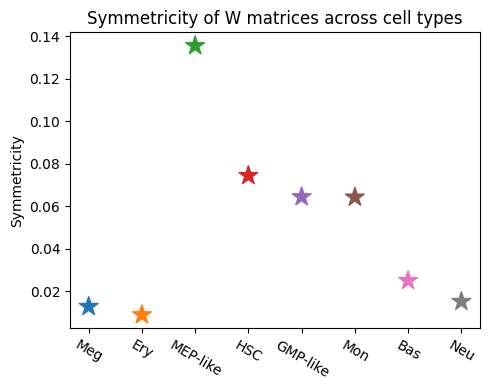

In [18]:
def symmetricity(A, norm=2):
    """Ratio of symmetric to total Frobenius norm."""
    S  = np.linalg.norm((A + A.T) / 2, ord=norm)
    As = np.linalg.norm((A - A.T) / 2, ord=norm)
    return (S - As) / (S + As)

genes_used = adata.var['use_for_dynamics'].values
W = {
    cluster: adata.varp[f'W_{cluster}'][genes_used][:, genes_used]
    for cluster in CELL_TYPE_ORDER
}

syms = np.array([symmetricity(W[k]) for k in CELL_TYPE_ORDER])

fig, ax = plt.subplots(figsize=(5, 4), tight_layout=True)
ax.scatter(
    range(len(CELL_TYPE_ORDER)), syms, s=200, marker='*',
    c=[colors[k] for k in CELL_TYPE_ORDER]
)
ax.set_xticks(range(len(CELL_TYPE_ORDER)))
ax.set_xticklabels(CELL_TYPE_ORDER, rotation=-30)
ax.set_ylabel('Symmetricity')
ax.set_title('Symmetricity of W matrices across cell types')
plt.show()


 ## 3.3 Network Centrality



 Three complementary centrality measures:

 - **degree_centrality_out**: fraction of outgoing edges

 - **betweenness_centrality**: fraction of shortest paths through node

 - **eigenvector_centrality**: influence weighted by neighbour importance

In [19]:
sch.tl.compute_network_centrality(
    adata,
    cluster_key=CLUSTER_KEY,
    threshold_number=40000   # keep top-N edges per cluster
)


/home/bernaljp/packages/scHopfield/scHopfield/tools/networks.py:304: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:102
  result_df["eigenvector_centrality"] = g.eigenvector_centrality(directed=True, weights="weight")
/home/bernaljp/packages/scHopfield/scHopfield/tools/networks.py:304: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:102
  result_df["eigenvector_centrality"] = g.eigenvector_centrality(directed=True, weights="weight")
/home/bernaljp/packages/scHopfield/scHopfield/tools/networks.py:304: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector c

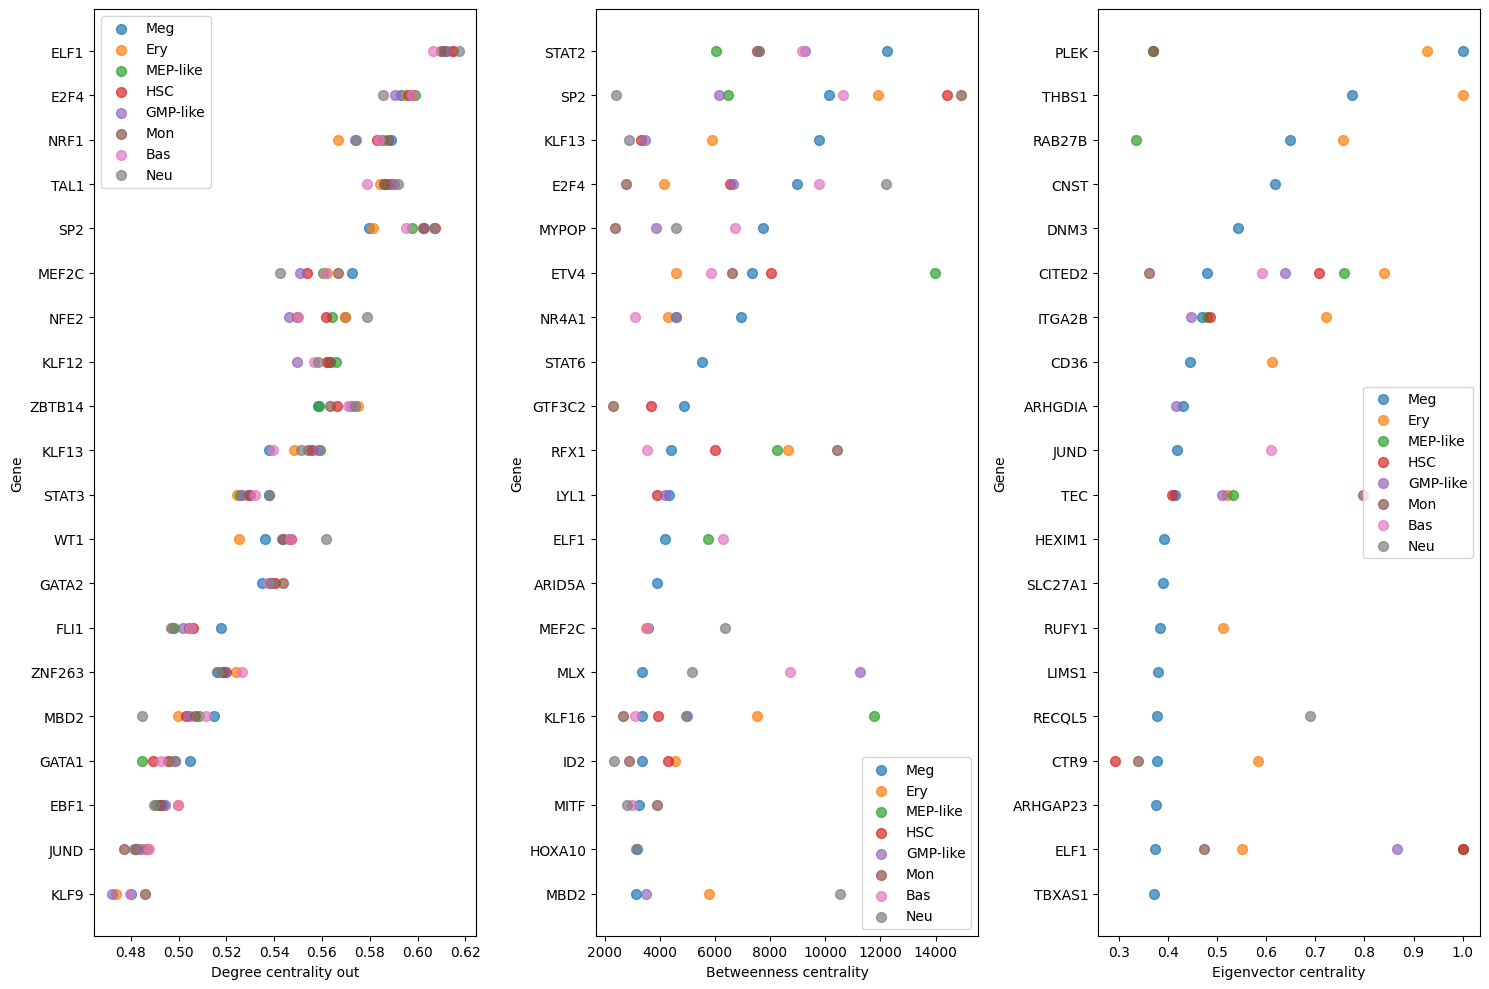

In [20]:
# Ranked gene plots for each metric
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

metrics = ['degree_centrality_out', 'betweenness_centrality', 'eigenvector_centrality']
for ax, metric in zip(axes, metrics):
    sch.pl.plot_network_centrality_rank(
        adata,
        metric=metric,
        clusters=CELL_TYPE_ORDER,
        cluster_key=CLUSTER_KEY,
        n_genes=20,
        colors=colors,
        ax=ax
    )
plt.tight_layout()
plt.show()


In [23]:
# Top-gene tables
df_betweenness = sch.tl.get_top_genes_table(
    adata,
    metric='betweenness_centrality',
    cluster_key=CLUSTER_KEY,
    n_genes=20,
    order=CELL_TYPE_ORDER
)
print("Betweenness centrality top genes:")
df_betweenness

Betweenness centrality top genes:


Meg                            Ery                        MEP-like  \
      Gene Betweenness Centrality    Gene Betweenness Centrality     Gene   
0    STAT2                12250.0     SP2                11927.0     ETV4   
1      SP2                10144.0    RFX1                 8652.0    KLF16   
2    KLF13                 9788.0   KLF16                 7518.0     NRF1   
3     E2F4                 8986.0    KLF9                 7180.0     CUX1   
4    MYPOP                 7762.0    JUND                 6566.0     RFX1   
5     ETV4                 7360.0   STAT3                 6291.0    ATF6B   
6    NR4A1                 6963.0    NRF1                 6190.0      SP2   
7    STAT6                 5544.0   KLF13                 5881.0    STAT2   
8   GTF3C2                 4864.0  HIVEP1                 5876.0     ELF1   
9     RFX1                 4404.0    MBD2                 5777.0     EBF1   
10    LYL1                 4319.0     WT1                 4853.0      HLF   
11    ELF1                 4196.0    ETV4                 4590.0    NR4A1   
12  ARID5A                 3900.0     ID2                 4564.0     AHRR   
13   MEF2C                 3583.0    NFE2                 4552.0   POU6F1   
14     MLX                 3372.0   NR4A1                 4284.0     JUND   
15   KLF16                 3349.0    ETV6                 4188.0    ZBTB4   
16     ID2                 3348.0    E2F4                 4160.0     TCF3   
17    MITF                 3261.0    TCF3                 3910.0    FOSL2   
18  HOXA10                 3191.0    CUX1                 3501.0     KLF9   
19    MBD2                 3124.0   MEF2C                 3495.0    STAT3   

                              HSC                        GMP-like  \
   Betweenness Centrality    Gene Betweenness Centrality     Gene   
0                 13980.5    KLF9                14669.0      MLX   
1                 11760.5     SP2                14413.0    STAT2   
2                 11469.0    ETV4                 8021.0     KLF9   
3                  8931.5    AHRR                 7765.0     E2F4   
4                  8260.0   STAT2                 7544.0      SP2   
5                  6912.0    EBF1                 6844.0    ZBTB4   
6                  6479.0    E2F4                 6531.0     NFE2   
7                  6031.0    NRF1                 6247.0    KLF16   
8                  5746.0    RFX1                 5999.0     EBF1   
9                  5078.5    JUND                 5013.0    NR4A1   
10                 4986.0   STAT3                 4977.0     KLF1   
11                 4575.0     ID2                 4289.0    ITGB2   
12                 4477.0   MEIS1                 3983.0     LYL1   
13                 4411.0   KLF16                 3947.0     NRF1   
14                 4033.5    LYL1                 3914.0    MYPOP   
15                 3943.0    TCF3                 3798.0     AHRR   
16                 3794.0     WT1                 3706.0     MBD2   
17                 3654.0  GTF3C2                 3684.0    KLF13   
18                 3516.0  HIVEP1                 3572.0     CUX1   
19                 3244.0   KLF13                 3336.0   HIVEP1   

                              Mon                            Bas  \
   Betweenness Centrality    Gene Betweenness Centrality    Gene   
0                 11277.0     SP2                14913.0     SP2   
1                  9261.0    RFX1                10432.0    E2F4   
2                  7476.0    TCF3                 9838.0   STAT2   
3                  6669.0   STAT2                 7591.0     MLX   
4                  6167.0    NRF1                 7298.0   ATF6B   
5                  5963.0    ETV4                 6633.0  HIVEP1   
6                  5612.0    MYCN                 5684.0   MYPOP   
7                  4984.0    KLF9                 5648.0    ELF1   
8                  4781.0    AHRR                 4976.0    AHRR   
9                  4596.0   STAT3            

In [24]:
df_degree = sch.tl.get_top_genes_table(
    adata,
    metric='degree_centrality_out',
    cluster_key=CLUSTER_KEY,
    n_genes=20,
    order=CELL_TYPE_ORDER
)
print("\nDegree centrality top genes:")
df_degree



Degree centrality top genes:


Meg                           Ery                       MEP-like  \
      Gene Degree Centrality Out    Gene Degree Centrality Out     Gene   
0     ELF1              0.612044    ELF1              0.614360     ELF1   
1     E2F4              0.592936    E2F4              0.595252     E2F4   
2     NRF1              0.588882    TAL1              0.584250      SP2   
3     TAL1              0.586566     SP2              0.581355     TAL1   
4      SP2              0.579618  ZBTB14              0.574986     NRF1   
5    MEF2C              0.572669    NFE2              0.569774    KLF12   
6     NFE2              0.569774    NRF1              0.566879     NFE2   
7    KLF12              0.563405   MEF2C              0.562247    MEF2C   
8   ZBTB14              0.558193   KLF12              0.562247    KLF13   
9    KLF13              0.537927   KLF13              0.548350   ZBTB14   
10   STAT3              0.537927   GATA2              0.539085      WT1   
11     WT1              0.536190     WT1              0.525188    GATA2   
12   GATA2              0.535032   STAT3              0.524609    STAT3   
13    FLI1              0.517661  ZNF263              0.524030   ZNF263   
14  ZNF263              0.515924    MBD2              0.499710     MBD2   
15    MBD2              0.514765    EBF1              0.499710     FLI1   
16   GATA1              0.504922    FLI1              0.497394     EBF1   
17    EBF1              0.493341   GATA1              0.496236    GATA1   
18    JUND              0.486972    JUND              0.486393     JUND   
19    KLF9              0.480023    KLF9              0.473654    STAT2   

                             HSC                       GMP-like  \
   Degree Centrality Out    Gene Degree Centrality Out     Gene   
0               0.610886    ELF1              0.614939     ELF1   
1               0.598726     SP2              0.607412      SP2   
2               0.597568    E2F4              0.597568     E2F4   
3               0.587145    TAL1              0.588882     TAL1   
4               0.585408    NRF1              0.583092     NRF1   
5               0.565721  ZBTB14              0.566300   ZBTB14   
6               0.563984   KLF12              0.562247    KLF13   
7               0.560510    NFE2              0.561668    MEF2C   
8               0.559351   KLF13              0.555877    KLF12   
9               0.558772   MEF2C              0.553561     NFE2   
10              0.546034     WT1              0.547192      WT1   
11              0.538506   GATA2              0.540243    GATA2   
12              0.525767   STAT3              0.529241    STAT3   
13              0.518819  ZNF263              0.519977   ZNF263   
14              0.508396    FLI1              0.506080     MBD2   
15              0.497973    MBD2              0.503185     FLI1   
16              0.490446    EBF1              0.492183    GATA1   
17              0.484655   GATA1              0.489288     EBF1   
18              0.482339    JUND              0.482339     JUND   
19              0.474812   STAT2              0.470759     KLF9   

                             Mon                           Bas  \
   Degree Centrality Out    Gene Degree Centrality Out    Gene   
0               0.612044    ELF1              0.609728    ELF1   
1               0.602779     SP2              0.602200    E2F4   
2               0.590620    E2F4              0.595831     SP2   
3               0.590041    NRF1              0.587724    NRF1   
4               0.573827    TAL1              0.585987    TAL1   
5               0.572090   MEF2C              0.566879  ZBTB14   
6               0.558193  ZBTB14              0.563405   MEF2C   
7               0.550666   KLF12              0.563405   KLF12   
8               0.549508   KLF13              0.554140    NFE2   
9               0.546034    NFE2              0.549508     WT1   
10              0.543138   GATA2              0.543717   KLF13   
11              0.53792

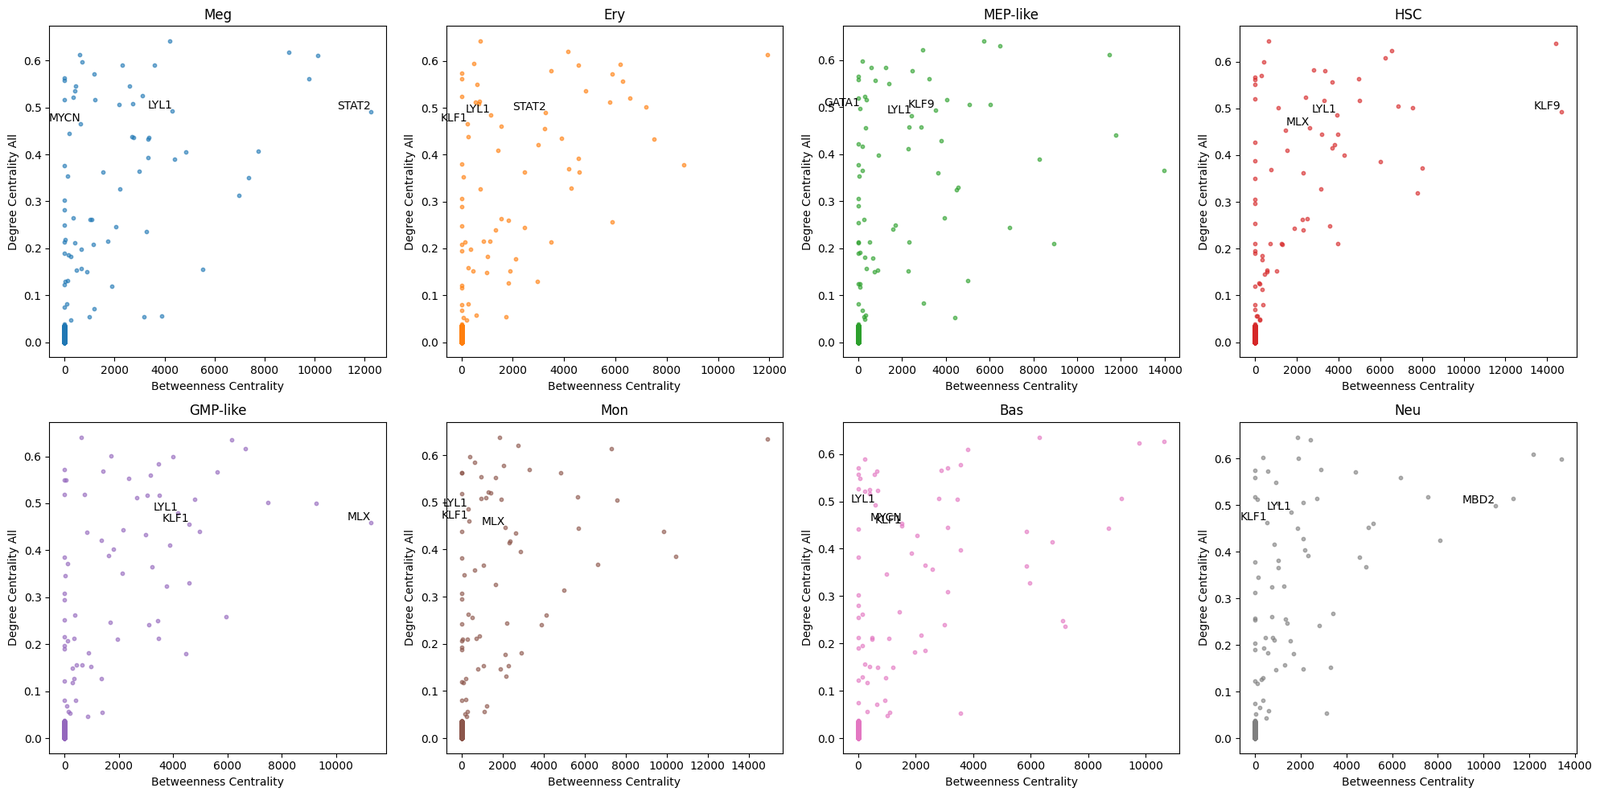

In [25]:
# Betweenness vs degree scatter (high betweenness, low degree = bottleneck genes)
fig = sch.pl.plot_centrality_scatter(
    adata,
    x_metric='betweenness_centrality',
    y_metric='degree_centrality_all',
    cluster_key=CLUSTER_KEY,
    order=CELL_TYPE_ORDER,
    colors=colors,
    n_top_genes=3,
    filter_threshold=('degree_centrality_all', '<', 0.5),
    figsize=(20, 10)
)
plt.show()


 ## 3.4 Eigenanalysis



 Eigendecomposition of each cluster's W matrix reveals:

 - Dominant regulatory directions (top eigenvector genes)

 - Stability indicators (sign of leading eigenvalue)

In [26]:
sch.tl.compute_eigenanalysis(adata, cluster_key=CLUSTER_KEY)


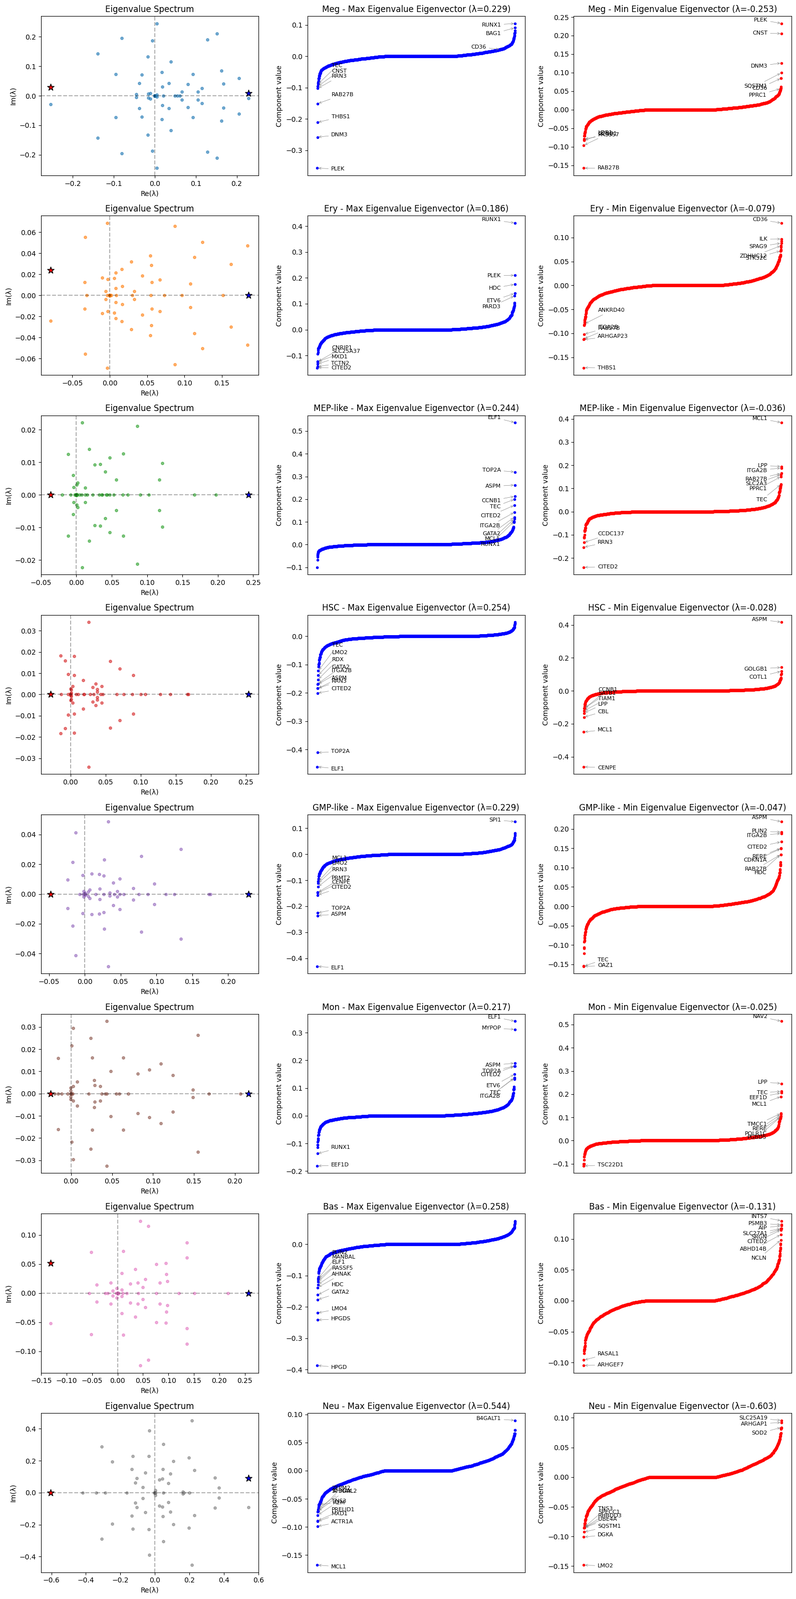

In [27]:
# Comprehensive grid: spectrum + max/min eigenvector gene loadings
fig = sch.pl.plot_eigenanalysis_grid(
    adata,
    cluster_key=CLUSTER_KEY,
    order=CELL_TYPE_ORDER,
    colors=colors,
    n_genes=10,
    figsize=(16, 4 * len(CELL_TYPE_ORDER))
)
plt.show()


In [32]:
# Table of top genes from extreme eigenvectors
df_eigenanalysis = sch.tl.get_eigenanalysis_table(
    adata,
    cluster_key=CLUSTER_KEY,
    n_genes=20,
    order=CELL_TYPE_ORDER
)
df_eigenanalysis.head(10)


Meg                                     Ery                      \
  +EV gene +EV value  -EV gene -EV value  +EV gene +EV value  -EV gene   
0     PLEK    -0.357      PLEK     0.233     RUNX1     0.412     THBS1   
1     DNM3    -0.258      CNST     0.205      PLEK     0.210      CD36   
2    THBS1    -0.211    RAB27B    -0.158       HDC     0.175  ARHGAP23   
3   RAB27B    -0.151      DNM3     0.126    CITED2    -0.147    RAB27B   
4    RUNX1     0.105    SQSTM1     0.099     TCTN2    -0.143    ITGA2B   
5     RRN3    -0.103     CCNB1    -0.096      ETV6     0.140       ILK   
6     CNST    -0.096  TMEM229B     0.086      MXD1    -0.132    CITED2   
7     BAG1     0.091      CD36     0.085     PARD3     0.130     SPAG9   
8      TEC    -0.089      LDB1    -0.083  SLC25A37    -0.124  SLC25A37   
9  ABHD14A    -0.087     THBS1    -0.081    CNRIP1    -0.124   ZDHHC12   

            MEP-like            ...      Mon                Bas            \
  -EV value +EV gene +EV value  ... -EV gene -EV value +EV gene +EV value   
0    -0.172     ELF1     0.537  ...     NAV2     0.514     HPGD    -0.387   
1     0.130    TOP2A     0.320  ...      LPP     0.246    HPGDS    -0.242   
2    -0.113     ASPM     0.262  ...      TEC     0.212     LMO4    -0.219   
3    -0.111    CCNB1     0.212  ...    EEF1D     0.206    GATA2    -0.177   
4    -0.102      TEC     0.200  ...     MCL1     0.190      HDC    -0.162   
5     0.097   CITED2     0.174  ...    TMCC1     0.117    AHNAK    -0.138   
6     0.092   ITGA2B     0.143  ...     RERE     0.113   RASSF5    -0.129   
7     0.088    GATA2     0.121  ...  TSC22D1    -0.109     ELF1    -0.121   
8    -0.083     MCL1     0.113  ...   POLR1C     0.104   MANBAL    -0.114   
9     0.083    RUNX1     0.102  ...    PGBD5     0.102    PLIN2    -0.109   

                          Neu                                
  -EV gene -EV value +EV gene +EV value  -EV gene -EV value  
0    INTS7     0.130     MCL1    -0.168      LMO2    -0.148  
1    PSMB3     0.123   ACTR1A    -0.099      DGKA    -0.101  
2      AIP     0.122     MXD1    -0.090  SLC25A19     0.096  
3  SLC27A1     0.117  B4GALT1     0.089    SQSTM1    -0.092  
4     SRGN     0.117  PRELID1    -0.089   ARHGAP1     0.092  
5   CITED2     0.115     TNS3    -0.079     UBE4A    -0.086  
6  ABHD14B     0.107    ZFPM2    -0.073    RHBDD3    -0.085  
7  ARHGEF7    -0.105     SNCA     0.073    SPECC1    -0.085  
8     NCLN     0.098  ST3GAL2    -0.072      TNS3    -0.084  
9   RASAL1    -0.096    CPNE9     0.072      SOD2     0.084  

[10 rows x 32 columns]

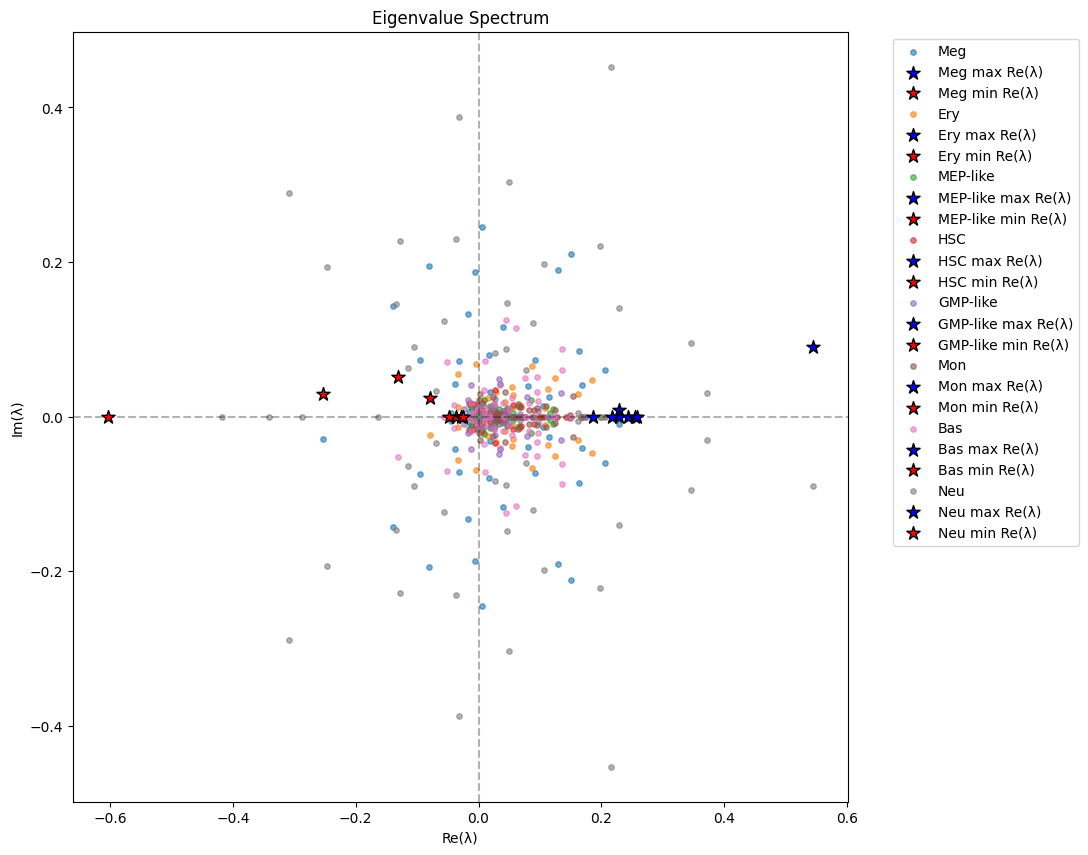

In [29]:
# Eigenvalue spectra for all clusters overlaid
fig, ax = plt.subplots(figsize=(10, 10))
sch.pl.plot_eigenvalue_spectrum(
    adata,
    clusters=CELL_TYPE_ORDER,
    cluster_key=CLUSTER_KEY,
    colors=colors,
    highlight_extremes=True,
    ax=ax
)
plt.show()


In [30]:
# Leading eigenvector per cluster — extreme eigenvalues summary
print("Extreme eigenvalues per cluster:")
for cluster in CELL_TYPE_ORDER:
    evals = adata.uns['scHopfield']['eigenanalysis'][f'eigenvalues_{cluster}']
    max_ev = evals[np.argmax(evals.real)]
    min_ev = evals[np.argmin(evals.real)]
    print(f"  {cluster:15s} | Max Re(λ): {max_ev.real:8.3f} | Min Re(λ): {min_ev.real:8.3f}")


Extreme eigenvalues per cluster:
  Meg             | Max Re(λ):    0.229 | Min Re(λ):   -0.253
  Ery             | Max Re(λ):    0.186 | Min Re(λ):   -0.079
  MEP-like        | Max Re(λ):    0.244 | Min Re(λ):   -0.036
  HSC             | Max Re(λ):    0.254 | Min Re(λ):   -0.028
  GMP-like        | Max Re(λ):    0.229 | Min Re(λ):   -0.047
  Mon             | Max Re(λ):    0.217 | Min Re(λ):   -0.025
  Bas             | Max Re(λ):    0.258 | Min Re(λ):   -0.131
  Neu             | Max Re(λ):    0.544 | Min Re(λ):   -0.603


 ## 3.5 GRN Visualisation

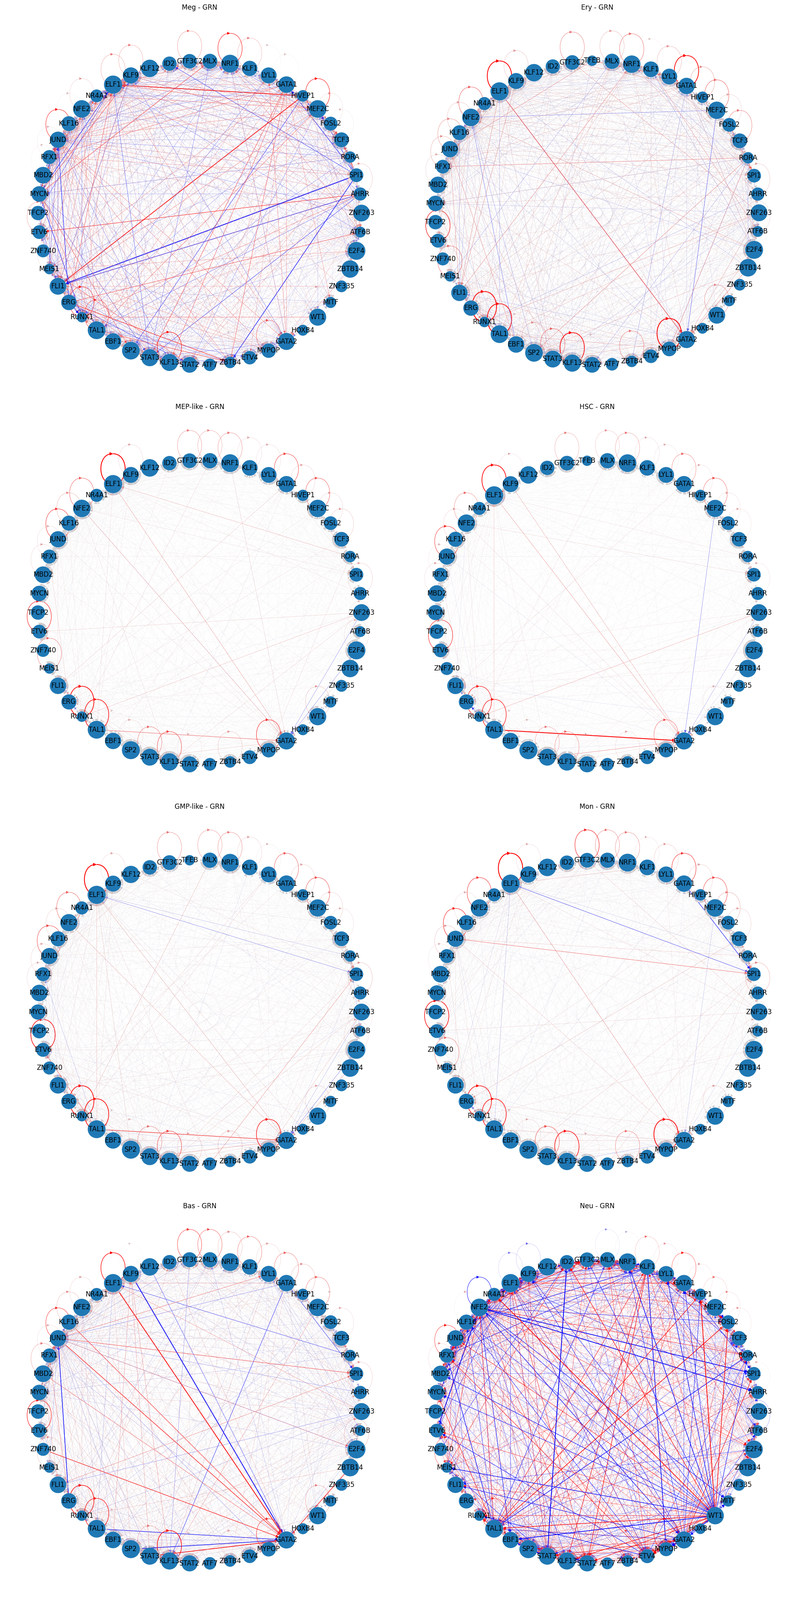

In [31]:
from matplotlib.colors import LinearSegmentedColormap

colors_graph = ['blue', 'lightgray', 'red']
custom_cmap  = LinearSegmentedColormap.from_list('custom_cmap', list(zip([0, 0.5, 1], colors_graph)))

score = 'degree_centrality_out'
topn  = 50

fig, axs = plt.subplots(4, 2, figsize=(20, 40), tight_layout=True)

for cluster, ax in zip(CELL_TYPE_ORDER, axs.flat):
    ax.axis('off')
    ax.set_title(f'{score.replace("_", " ").capitalize()} — {cluster}')
    sch.pl.plot_grn_network(
        adata,
        cluster=cluster,
        topn=topn,
        score_size=score,
        ax=ax,
        cmap=custom_cmap
    )

plt.show()
